In [10]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.special import binom, factorial

In [6]:
data = pd.read_csv('/home/tommaso/new_phd/data/Araya_nucleotides.csv',index_col=0)

data = data.drop(['25','26','27'],axis=1) # drop odd positions

collapsed_df = data.groupby(list(data.columns[:99]), as_index=False).sum()
data = collapsed_df.sort_values('T0_rep1', ascending=False)

data

,1,2,3,4,5,6,7,8,9,10,...,95,96,97,98,99,100,101,102,T0_rep1,T0_rep2
1187499,2,0,1,2,3,3,1,1,0,1,...,0,1,1,1,2,1,2,3,341899.0,489213.0
1187443,2,0,1,2,3,3,1,1,0,1,...,0,1,1,1,0,1,2,3,6825.0,10250.0
1187491,2,0,1,2,3,3,1,1,0,1,...,0,1,1,1,2,1,0,3,6222.0,9055.0
1187033,2,0,1,2,3,3,1,1,0,1,...,0,1,1,1,2,1,2,3,5976.0,8371.0
1185091,2,0,1,2,3,3,1,1,0,1,...,0,1,1,1,2,1,2,3,5717.0,8192.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1114066,2,0,1,2,3,3,1,1,0,1,...,0,1,1,1,2,1,2,3,0.0,1.0
1114065,2,0,1,2,3,3,1,1,0,1,...,0,1,1,1,2,1,2,3,0.0,1.0
1114064,2,0,1,2,3,3,1,1,0,1,...,0,1,1,1,2,1,2,3,0.0,1.0
1114062,2,0,1,2,3,3,1,1,0,1,...,0,1,1,1,2,2,2,3,0.0,1.0


In [7]:
wt = data.iloc[0,:99].to_numpy()

data['ham_dist'] = 0
for pos in range(99):
    if pos % 10 == 0:
        print(pos)
    data['ham_dist'] += (data.iloc[:,pos] != wt[pos]).astype('int')
    
data

0
10
20
30
40
50
60
70
80
90


,1,2,3,4,5,6,7,8,9,10,...,96,97,98,99,100,101,102,T0_rep1,T0_rep2,ham_dist
1187499,2,0,1,2,3,3,1,1,0,1,...,1,1,1,2,1,2,3,341899.0,489213.0,0
1187443,2,0,1,2,3,3,1,1,0,1,...,1,1,1,0,1,2,3,6825.0,10250.0,1
1187491,2,0,1,2,3,3,1,1,0,1,...,1,1,1,2,1,0,3,6222.0,9055.0,1
1187033,2,0,1,2,3,3,1,1,0,1,...,1,1,1,2,1,2,3,5976.0,8371.0,1
1185091,2,0,1,2,3,3,1,1,0,1,...,1,1,1,2,1,2,3,5717.0,8192.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1114066,2,0,1,2,3,3,1,1,0,1,...,1,1,1,2,1,2,3,0.0,1.0,3
1114065,2,0,1,2,3,3,1,1,0,1,...,1,1,1,2,1,2,3,0.0,1.0,3
1114064,2,0,1,2,3,3,1,1,0,1,...,1,1,1,2,1,2,3,0.0,1.0,3
1114062,2,0,1,2,3,3,1,1,0,1,...,1,1,1,2,2,2,3,0.0,1.0,4


## model parameters

In [8]:
D = data.iloc[:,-3:-1].sum()

df_p = pd.DataFrame(index=range(99), columns=['T0_rep1','T0_rep2'])
for i in range(99):
    df_p.iloc[i] = data.query('ham_dist == %s'%i).iloc[:,-3:-1].sum()
    
df_p = df_p/D
df_logp = np.log(df_p.astype('float'))

/home/tommaso/.local/lib/python3.10/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


In [14]:
df_p.to_csv('df_p.csv')

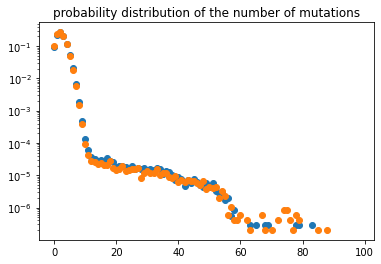

In [15]:
plt.scatter(df_p.index, df_p.T0_rep1, label='rep1')
plt.scatter(df_p.index, df_p.T0_rep2, label='rep2')
plt.yscale('log')
plt.title('probability distribution of the number of mutations')
plt.savefig('mutations_pdf.png')

In [24]:
# frequencies from all data
for replicate in ['T0_rep1','T0_rep2']:

    freq = np.zeros([99,4])

    for pos in range(99):
        for a in range(4):
            freq[pos, a] = ((data.iloc[:, pos] == a).astype('int') * data[replicate]).sum()

    # matrix of transfer
    t_matrix = np.zeros([4,4])

    for pos1 in range(4):
        for pos2 in range(4):
            if pos1 != pos2:
                t_matrix[pos1, pos2]=freq[freq.argmax(axis=1) == pos1].sum(0)[pos2]
    t_matrix = t_matrix / t_matrix.sum(1)[:,None]
    t_matrix = np.log(t_matrix)

    np.savetxt('t_matrix_%s.csv'%replicate,t_matrix, delimiter=',')

/tmp/ipykernel_21458/3301042702.py:18: RuntimeWarning: divide by zero encountered in log
  t_matrix = np.log(t_matrix)


## actual binning function

In [258]:
ham_dist = 2
replicate = 'T0_rep2'
data_sel = data.query('%s > 0 and ham_dist == %d'%(replicate, ham_dist))

df_p = pd.read_csv('df_p.csv',index_col=0)
t_matrix = np.loadtxt('t_matrix_%s.csv'%replicate, delimiter=',')

wt = data.iloc[0,:99].to_numpy().astype('int')

In [259]:
for i in range(ham_dist):
    data_sel['m%d'%i] = 0

data_sel['where'] = 0


for pos in range(99):
    bool_vect = (data_sel.iloc[:,pos] != wt[pos]).astype('int')
    for i in np.arange(ham_dist)[::-1]:
        bool2 = (data_sel['where'] == i).astype('int')
        bool_prod = bool_vect * bool2
        index_sel = bool_prod.loc[bool_prod == 1].index
        data_sel.loc[index_sel,'m%d'%i] = data_sel.loc[index_sel].iloc[:,pos] + 4*wt[pos]
        data_sel.loc[index_sel,'where'] += 1
        
data_sel

/tmp/ipykernel_21458/2207171651.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sel['m%d'%i] = 0
/tmp/ipykernel_21458/2207171651.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sel['m%d'%i] = 0
/tmp/ipykernel_21458/2207171651.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retur

,1,2,3,4,5,6,7,8,9,10,...,99,100,101,102,T0_rep1,T0_rep2,ham_dist,m0,m1,where
1186677,2,0,1,2,3,3,1,1,0,1,...,0,1,2,3,135.0,207.0,2,8,8,2
1185835,2,0,1,2,3,3,1,1,0,1,...,0,1,2,3,129.0,181.0,2,8,8,2
1185066,2,0,1,2,3,3,1,1,0,1,...,0,1,2,3,128.0,166.0,2,8,8,2
1187014,2,0,1,2,3,3,1,1,0,1,...,0,1,2,3,122.0,178.0,2,8,8,2
1187436,2,0,1,2,3,3,1,1,0,1,...,0,1,0,3,119.0,177.0,2,8,8,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
917322,2,0,1,2,3,3,1,1,0,1,...,2,1,2,0,0.0,6.0,2,14,12,2
932602,2,0,1,2,3,3,1,1,0,1,...,2,1,2,3,0.0,6.0,2,12,13,2
937288,2,0,1,2,3,3,1,1,0,1,...,2,1,2,3,0.0,7.0,2,13,12,2
1186388,2,0,1,2,3,3,1,1,0,1,...,2,1,2,3,0.0,24.0,2,4,9,2


In [260]:
_, wt_ab = np.unique(wt, return_counts=True)
wt_ab

array([21, 31, 26, 21])

In [261]:
def dispositions(n,k):
    return factorial(n) / factorial(n-k)

In [262]:
df_prel = pd.DataFrame(columns=['label','n_lambdas','n_nonzeros','log_lambda','sum_counts','sum_counts_2'])
D = data_sel[replicate].sum()

j = 0

data_sel['group_key'] = data_sel.apply(lambda row: tuple(sorted([row['m%d'%i] for i in range(ham_dist)])), axis=1)
for label, data_l in data_sel.groupby('group_key'):
    
    #compute n_lambdas
    label_array = np.array(list(label))
    class_, freq_ = np.unique((label_array / 4).astype('int'),return_counts=True)
    n_lambdas = dispositions(wt_ab[class_],freq_).prod()
    _, freq1_ = np.unique(label_array.astype('int'),return_counts=True)
    n_lambdas /= factorial(freq1_).prod()
    #print(wt_ab[class_],freq_, n_lambdas, factorial(freq1_).prod())
        
    #compute other quantities
    n_nonzeros = len(data_l)
    log_lambda = t_matrix.reshape(-1)[label_array.astype('int')].sum() + np.log(D) - np.log(binom(99, ham_dist))
    sum_counts = data_l[replicate].sum()
    sum_counts_2 = (data_l[replicate]**2).sum()
    
    df_prel.loc[j] = [label, n_lambdas, n_nonzeros, log_lambda, sum_counts, sum_counts_2]
    j+=1

/tmp/ipykernel_21458/2878524508.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sel['group_key'] = data_sel.apply(lambda row: tuple(sorted([row['m%d'%i] for i in range(ham_dist)])), axis=1)


In [263]:
df_prel.to_csv('df_prel_Araya_%s_ham%d.csv'%(replicate, ham_dist))

## Fano-factor computation

In [264]:
for replicate in ['T0_rep1','T0_rep2']:
    for ham_dist in range(2,9):
        df_prel = pd.read_csv('df_prel_Araya_%s_ham%d.csv'%(replicate, ham_dist))

        df_prel['mean_lambda'] = np.exp(df_prel['log_lambda'])
        df_prel['mean_count'] = df_prel['sum_counts'] / df_prel['n_lambdas']

        #df_prel['var_count'] = ((df_prel['mean_count']**2)*(df_prel['n_lambdas']-df_prel['n_nonzeros']) + df_prel['sum_counts_2'])/ df_prel['n_lambdas']
        df_prel['var_count'] = (df_prel['sum_counts_2'] /df_prel['n_lambdas']) - (df_prel['mean_count'])**2
        
        
        df_prel[['label','n_lambdas','n_nonzeros','log_lambda','sum_counts','sum_counts_2','mean_lambda','mean_count','var_count']].to_csv('df_prel_Araya_%s_ham%d.csv'%(replicate, ham_dist))

## preliminary plots

In [265]:
ham_dist = 2
replicate = 'T0_rep2'
df_prel = pd.read_csv('df_prel_Araya_%s_ham%d.csv'%(replicate, ham_dist),index_col=0)

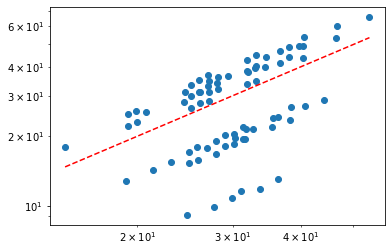

In [266]:
vmin = df_prel['mean_lambda'].min()
vmax = df_prel['mean_lambda'].max()

plt.scatter(df_prel['mean_lambda'],df_prel['mean_count'])
plt.plot([vmin,vmax],[vmin,vmax],color='red', linestyle='--')
plt.xscale('log')
plt.yscale('log')

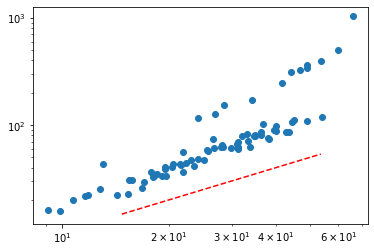

In [267]:
plt.scatter(df_prel['mean_count'],df_prel['var_count'])
plt.plot([vmin,vmax],[vmin,vmax],color='red', linestyle='--')
plt.xscale('log')
plt.yscale('log')

## binning

In [208]:
replicate = 'T0_rep2'
ham_dist = 8
df_prel = pd.read_csv('df_prel_Araya_%s_ham%d.csv'%(replicate, ham_dist),index_col=0)
df_prel['F'] = df_prel['var_count'] / df_prel['mean_count']

df_prel = df_prel.sort_values('log_lambda', ascending=False)

print(df_prel['n_nonzeros'].sum())
print('number of bins: ',int(df_prel['n_nonzeros'].sum() / 1e4)+1)

6522
number of bins:  1


In [209]:
nbins = 1
df_bins = pd.DataFrame(index=np.arange(nbins), columns=['edge_sx','edge_dx','n_lambdas','n_nonzeros','mean_lambda','var_lambda','mean_count','var_count'])

split = np.array_split(df_prel,nbins)
for i in range(nbins):
    df_prel_split = split[i]
    edge_sx = df_prel_split['log_lambda'].min()
    edge_dx = df_prel_split['log_lambda'].max()
    n_lambdas = df_prel_split['n_lambdas'].sum()
    n_nonzeros = df_prel_split['n_nonzeros'].sum()
    mean_lambda = (df_prel_split['mean_lambda']*df_prel_split['n_lambdas']).sum() / n_lambdas
    var_lambda = ((df_prel_split['mean_lambda']**2)*df_prel_split['n_lambdas']).sum() / n_lambdas - mean_lambda**2
    mean_count = (df_prel_split['sum_counts']).sum() / n_lambdas
    var_count = (df_prel_split['sum_counts_2']).sum() / n_lambdas - mean_count**2
    
    df_bins.loc[i] = [edge_sx,edge_dx,n_lambdas,n_nonzeros,mean_lambda,var_lambda,mean_count,var_count]



df_bins['F'] = (df_bins['var_count']-df_bins['var_lambda']) / df_bins['mean_count']
df_bins.to_csv('df_bins_Araya_%s_ham%d.csv'%(replicate, ham_dist))

## preliminary plot

In [222]:
ham_dist = 4
replicate = 'T0_rep1'

df_bins = pd.read_csv('df_bins_Araya_%s_ham%d.csv'%(replicate, ham_dist),index_col=0)

In [223]:
df_bins

,edge_sx,edge_dx,n_lambdas,n_nonzeros,mean_lambda,var_lambda,mean_count,var_count,F
0,-5.871012,-5.606731,1731142.0,56,0.003078,6.197320e-08,0.000039,0.000051,1.326718
1,-5.989820,-5.871382,3305176.0,91,0.002629,1.120313e-08,0.000031,0.000040,1.271454
2,-6.088259,-5.992124,3998498.0,58,0.002363,6.535624e-09,0.000016,0.000019,1.187076
3,-6.123718,-6.090791,3498124.0,102,0.002220,3.482822e-10,0.000031,0.000035,1.129587
4,-6.206697,-6.130904,4003636.0,73,0.002118,3.144847e-09,0.000020,0.000025,1.222047
5,-6.237004,-6.206989,4751852.0,80,0.001988,4.241701e-10,0.000018,0.000022,1.183867
6,-6.282412,-6.239678,3324230.0,1143,0.001917,6.913651e-10,0.000393,0.000508,1.292102
7,-6.337975,-6.287463,4616724.0,151,0.001811,6.772985e-10,0.000037,0.000048,1.277401
8,-6.369882,-6.346867,4215512.0,2005,0.001735,1.438201e-10,0.000535,0.000668,1.248689
9,-6.403358,-6.372540,3106884.0,420,0.001681,2.824114e-10,0.000154,0.000198,1.288547


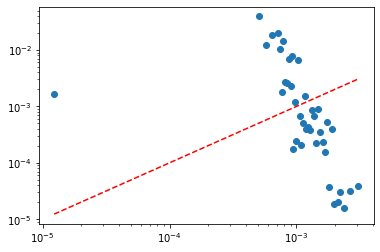

In [220]:
vmin = df_bins['mean_lambda'].min()
vmax = df_bins['mean_lambda'].max()

plt.scatter(df_bins['mean_lambda'],df_bins['mean_count'])
plt.plot([vmin,vmax],[vmin,vmax],color='red', linestyle='--')
plt.xscale('log')
plt.yscale('log')

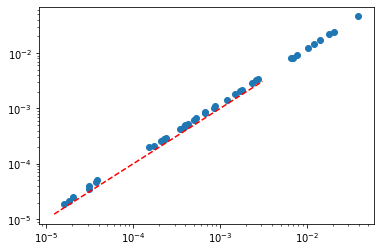

In [221]:
plt.scatter(df_bins['mean_count'],df_bins['var_count'])
plt.plot([vmin,vmax],[vmin,vmax],color='red', linestyle='--')
plt.xscale('log')
plt.yscale('log')